# Phase 2 — Feature Engineering
**ML Foundations Capstone | Titanic Dataset**

Starting from the cleaned dataset, we create features that are richer and more useful for analysis and modelling. Every new column includes a **WHY** explanation.

## 2.1 Imports & Load Clean Data

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

# Load the cleaned output from Phase 1
df = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv')

# Restore categorical dtypes (CSV does not preserve them)
df['survived'] = df['survived'].astype('category')
df['pclass']   = df['pclass'].astype('category')

print(f'Loaded: {df.shape}')
df.head()

Loaded: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2.2 One-Hot Encoding: `sex` and `embarked`

**WHY:** Models need numbers, not strings. One-hot encoding creates binary indicator columns without implying any false ordering between categories. `drop_first=True` removes one column per variable to avoid the dummy variable trap (perfect multicollinearity).

In [25]:
# One-hot encode 'sex' and 'embarked'; drop_first avoids multicollinearity
df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)

ohe_cols = [c for c in df.columns if c.startswith('sex_') or c.startswith('embarked_')]
print(f'New binary columns: {ohe_cols}')
df[ohe_cols].head(6)

New binary columns: ['sex_male', 'embarked_Q', 'embarked_S']


,sex_male,embarked_Q,embarked_S
0,True,False,True
1,False,False,False
2,False,False,True
3,False,False,True
4,True,False,True
5,True,True,False


## 2.3 Ordinal Encoding: `pclass`

**WHY:** Passenger class is ordered — 1st class is genuinely better than 3rd. We remap so **higher number = better class** (1st->3, 2nd->2, 3rd->1), making it directionally consistent with fare. This preserves the natural order that one-hot encoding would destroy.

In [26]:
# Remap: original 1 (best) -> 3, original 2 -> 2, original 3 (lowest) -> 1
pclass_map = {1: 3, 2: 2, 3: 1}
df['pclass_ordinal'] = df['pclass'].astype(int).map(pclass_map)

print('Ordinal encoding mapping (pclass -> pclass_ordinal):')
print(df[['pclass', 'pclass_ordinal']].drop_duplicates().sort_values('pclass'))

Ordinal encoding mapping (pclass -> pclass_ordinal):
  pclass  pclass_ordinal
1      1               3
9      2               2
0      3               1


## 2.4 StandardScaler: `age` and `fare`

**WHY:** Distance-based algorithms (k-NN, SVM) and gradient descent are sensitive to feature scale. StandardScaler transforms each column to mean=0, std=1 so age (range 0-80) and fare (range 0-500+) contribute equally to any model.

In [27]:
scaler = StandardScaler()

# Store scaled values as new columns to preserve originals for EDA charts
df[['age_scaled', 'fare_scaled']] = scaler.fit_transform(df[['age', 'fare']])

print('Scaled columns — should have mean~0 and std~1:')
print(df[['age_scaled', 'fare_scaled']].describe().loc[['mean', 'std']].round(4))

Scaled columns — should have mean~0 and std~1:
      age_scaled  fare_scaled
mean      0.0000       0.0000
std       1.0007       1.0006


## 2.5 Ratio Feature: `fare_per_class_unit`

**WHY:** A raw fare of 20 pounds means something very different for a 3rd-class ticket vs a 1st-class ticket. Dividing fare by the ordinal class score normalises spending relative to class level, revealing who over-paid or under-paid within their tier. Safe division guards against division by zero.

In [28]:
# Safe division: np.where prevents any division-by-zero errors
df['fare_per_class_unit'] = np.where(
    df['pclass_ordinal'] > 0,
    df['fare'] / df['pclass_ordinal'],
    0
)

print('fare_per_class_unit stats:')
print(df['fare_per_class_unit'].describe().round(2))

fare_per_class_unit stats:
count    891.00
mean      16.47
std       17.18
min        0.00
25%        7.75
50%        9.48
75%       18.71
max      170.78
Name: fare_per_class_unit, dtype: float64


## 2.6 Domain Feature: `family_size`

**WHY:** Historical accounts describe families struggling to evacuate together during the sinking. `family_size = sibsp + parch + 1` captures the full travel group size in one column. Solo travellers vs large family groups likely faced very different evacuation experiences.

In [29]:
# sibsp = siblings/spouses aboard; parch = parents/children aboard
# Add 1 to count the passenger themselves
df['family_size'] = df['sibsp'] + df['parch'] + 1

print('family_size distribution:')
print(df['family_size'].value_counts().sort_index())

family_size distribution:
family_size
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64


## 2.7 Interaction Feature: `class_fare_interaction`

**WHY:** The combination of high class AND high fare signals wealth more strongly than either feature alone. Multiplying `pclass_ordinal x fare_scaled` creates a composite luxury score. Interaction terms let linear models capture multiplicative (non-additive) relationships between features.

In [30]:
df['class_fare_interaction'] = df['pclass_ordinal'] * df['fare_scaled']

print('class_fare_interaction stats:')
print(df['class_fare_interaction'].describe().round(3))

class_fare_interaction stats:
count    891.000
mean       0.459
std        2.794
min       -1.945
25%       -0.492
50%       -0.424
75%       -0.062
max       29.001
Name: class_fare_interaction, dtype: float64


## 2.8 Log Transform: `fare`

**WHY:** `fare` is heavily right-skewed. A small number of very expensive first-class tickets drag the distribution far to the right. `np.log1p()` = log(1+x) compresses this tail into a much more symmetric shape, which benefits linear models and makes visualisations cleaner.

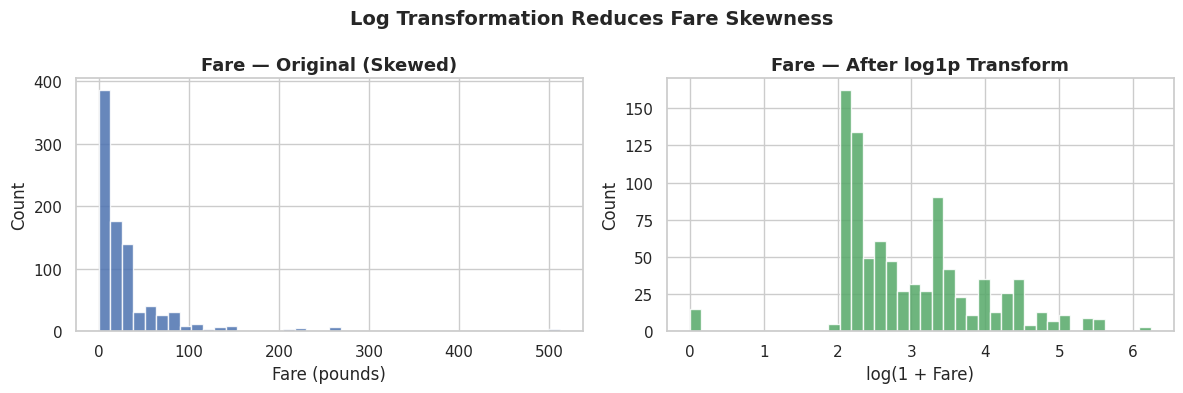

Skewness BEFORE: 4.787
Skewness AFTER:  0.395


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before: raw fare distribution
axes[0].hist(df['fare'], bins=40, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0].set_title('Fare — Original (Skewed)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Fare (pounds)')
axes[0].set_ylabel('Count')

# Apply the log transform
df['fare_log'] = np.log1p(df['fare'])

# After: log-transformed distribution
axes[1].hist(df['fare_log'], bins=40, color='#55A868', edgecolor='white', alpha=0.85)
axes[1].set_title('Fare — After log1p Transform', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(1 + Fare)')
axes[1].set_ylabel('Count')

plt.suptitle('Log Transformation Reduces Fare Skewness', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Skewness BEFORE: {df["fare"].skew():.3f}')
print(f'Skewness AFTER:  {df["fare_log"].skew():.3f}')

## 2.9 Bin `age` into Life-Stage Groups

**WHY:** Treating age as a continuous number assigns equal importance to every year gap. Grouping into life stages (Child, Youth, Adult, Middle-Aged, Senior) lets us analyse survival patterns at a meaningful level — a key question for the Titanic, where the evacuation order was 'women and children first'.

In [32]:
age_bins   = [0, 12, 18, 35, 60, float('inf')]
age_labels = ['Child', 'Youth', 'Adult', 'Middle-Aged', 'Senior']

df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=True)

print('Age group distribution:')
print(df['age_group'].value_counts().sort_index())

Age group distribution:
age_group
Child           69
Youth           70
Adult          358
Middle-Aged    195
Senior          22
Name: count, dtype: int64


## 2.10 Remove Redundant Features (correlation > 0.99)

**WHY:** Features with near-perfect correlation (r > 0.99) carry essentially identical information. We use a conservative 0.99 threshold here to only drop features that are exact linear transforms of another (such as `age_scaled` vs `age`), while preserving meaningful engineered features like `family_size` and `class_fare_interaction` that have slightly lower correlations with their source columns.

In [33]:
# Select numeric columns for correlation analysis
numeric_df  = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr().abs()

# Use upper triangle only — avoids counting each pair twice
upper   = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.99)]

print(f'Columns to drop (r > 0.99 with another feature): {to_drop}')

if to_drop:
    df = df.drop(columns=to_drop)
    print(f'Dropped: {to_drop}')
else:
    print('No redundant pairs found — all features retained.')

print(f'\nFinal dataset shape: {df.shape}')

Columns to drop (r > 0.99 with another feature): ['age_scaled', 'fare_scaled']
Dropped: ['age_scaled', 'fare_scaled']

Final dataset shape: (891, 22)


## 2.11 Save Feature-Engineered Dataset

In [34]:
print(f'Final shape: {df.shape}')
df.head()

Final shape: (891, 22)


,survived,pclass,age,sibsp,parch,fare,class,who,adult_male,deck,...,alone,sex_male,embarked_Q,embarked_S,pclass_ordinal,fare_per_class_unit,family_size,class_fare_interaction,fare_log,age_group
0,0,3,22.0,1,0,7.2500,Third,man,True,NaN,...,False,True,False,True,1,7.2500,2,-0.502445,2.110213,Adult
1,1,1,38.0,1,0,71.2833,First,woman,False,C,...,False,False,False,False,3,23.7611,2,2.360536,4.280593,Middle-Aged
2,1,3,26.0,0,0,7.9250,Third,woman,False,NaN,...,True,False,False,True,1,7.9250,1,-0.488854,2.188856,Adult
3,1,1,35.0,1,0,53.1000,First,woman,False,C,...,False,False,False,True,3,17.7000,2,1.262191,3.990834,Adult
4,0,3,35.0,0,0,8.0500,Third,man,True,NaN,...,True,True,False,True,1,8.0500,1,-0.486337,2.202765,Adult
